# Analisis Prediksi Pergerakan Harga Saham Indo Tambangraya Megah Tbk. Menggunakan Model LSTM Dengan Mempertimbangkan RSI Dan MA 50

In [50]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib
from tensorflow import keras
sns.set_style("whitegrid") 
plt.style.use("fivethirtyeight") 
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler 
import ta 
import warnings 
warnings.filterwarnings("ignore") 
from datetime import date 
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.initializers import Orthogonal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dropout, Dense # type: ignore
from sklearn.metrics import mean_squared_error, r2_score


# EDA(Exploration Data Analys)

In [51]:
url = 'D:/Kuliah/Semester6/PUI/project/static/files/Nickel.csv'
stock_data = pd.read_csv(url, encoding="UTF-8")
stock_data= pd.DataFrame(stock_data)
stock_data

,Date,Price,Open,High,Low,Vol.,Change %
0,01/15/2025,"15,850.00","15,895.00","15,900.00","15,895.00",NaN,-0.66%
1,01/14/2025,"15,956.00","15,850.00","15,830.00","15,835.00",23.06K,0.35%
2,01/13/2025,"15,901.00","15,780.00","15,775.00","15,780.00",26.28K,1.55%
3,01/10/2025,"15,658.00","15,620.00","15,590.00","15,600.00",18.70K,1.14%
4,01/09/2025,"15,482.00","15,450.00","15,400.00","15,450.00",15.01K,0.20%
...,...,...,...,...,...,...,...
4073,07/11/2008,"21,455.00","21,455.00","21,455.00","21,455.00",NaN,-1.40%
4074,07/10/2008,"21,760.00","21,760.00","21,760.00","21,760.00",NaN,2.12%
4075,07/09/2008,"21,309.00","21,309.00","21,309.00","21,309.00",NaN,4.15%
4076,07/08/2008,"20,460.00","20,460.00","20,460.00","20,460.00",NaN,-1.56%


In [52]:
def clean_convert(data):
    data_clean = data.replace(",", ".")
    data_clean = data_clean[:-3]
    return float(data_clean)

stock_data['Price'] = stock_data['Price'].apply(clean_convert).astype('float64')
stock_data['Open'] = stock_data['Open'].apply(clean_convert).astype('float64')
stock_data['High'] = stock_data['High'].apply(clean_convert).astype('float64')
stock_data['Low'] = stock_data['Low'].apply(clean_convert).astype('float64')


In [53]:
stock_data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4078 entries, 0 to 4077
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4078 non-null   object 
 1   Price     4078 non-null   float64
 2   Open      4078 non-null   float64
 3   High      4078 non-null   float64
 4   Low       4078 non-null   float64
 5   Vol.      1315 non-null   object 
 6   Change %  4078 non-null   object 
dtypes: float64(4), object(3)
memory usage: 223.1+ KB


In [54]:
stock_data.describe() 

,Price,Open,High,Low
count,4078.000000,4078.000000,4078.000000,4078.000000
mean,16.444064,16.447861,16.538281,16.344606
std,5.135359,5.142307,5.109980,5.165077
min,7.590000,7.655000,7.820000,7.550000
25%,12.690000,12.700500,12.835000,12.560000
50%,16.112000,16.100500,16.225000,16.005000
75%,19.109500,19.100750,19.193000,19.010750
max,81.051000,81.066000,86.791000,81.031000


In [55]:
stock_data.isnull().sum() # menghitung jumlah nilai-nilai yang hilang (NaN, null) dalam setiap kolom dari DataFrame

Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2763
Change %       0
dtype: int64

In [56]:
stock_data = stock_data.drop(['Vol.'],axis=1)
stock_data = stock_data.drop(['Change %'],axis=1)

In [57]:
### kolom 'date' dipecah menjadi dua bagian berdasarkan karakter spasi (" "). n = 1 ,dibagi satu kali
### ini akan menghasilkan DataFrame yang hanya berisi bagian tanggal (tanpa jam) setiap entri dalam kolom 'date'
stock_data['Date']= stock_data['Date'].str.split(" ", n = 1, expand = True)[0]
### mengonversi bagian tanggal ini menjadi format datetime yang sesuai
stock_data['Date']= pd.to_datetime(stock_data['Date'])

stock_data = stock_data.sort_values('Date', ascending=True)
stock_data['Date']

stock_data

,Date,Price,Open,High,Low
4077,2008-07-07,20.785,20.785,20.785,20.785
4076,2008-07-08,20.460,20.460,20.460,20.460
4075,2008-07-09,21.309,21.309,21.309,21.309
4074,2008-07-10,21.760,21.760,21.760,21.760
4073,2008-07-11,21.455,21.455,21.455,21.455
...,...,...,...,...,...
4,2025-01-09,15.482,15.450,15.400,15.450
3,2025-01-10,15.658,15.620,15.590,15.600
2,2025-01-13,15.901,15.780,15.775,15.780
1,2025-01-14,15.956,15.850,15.830,15.835


# Visualisasi Rata-Rata Close,Open, High,Low, Dan Volume

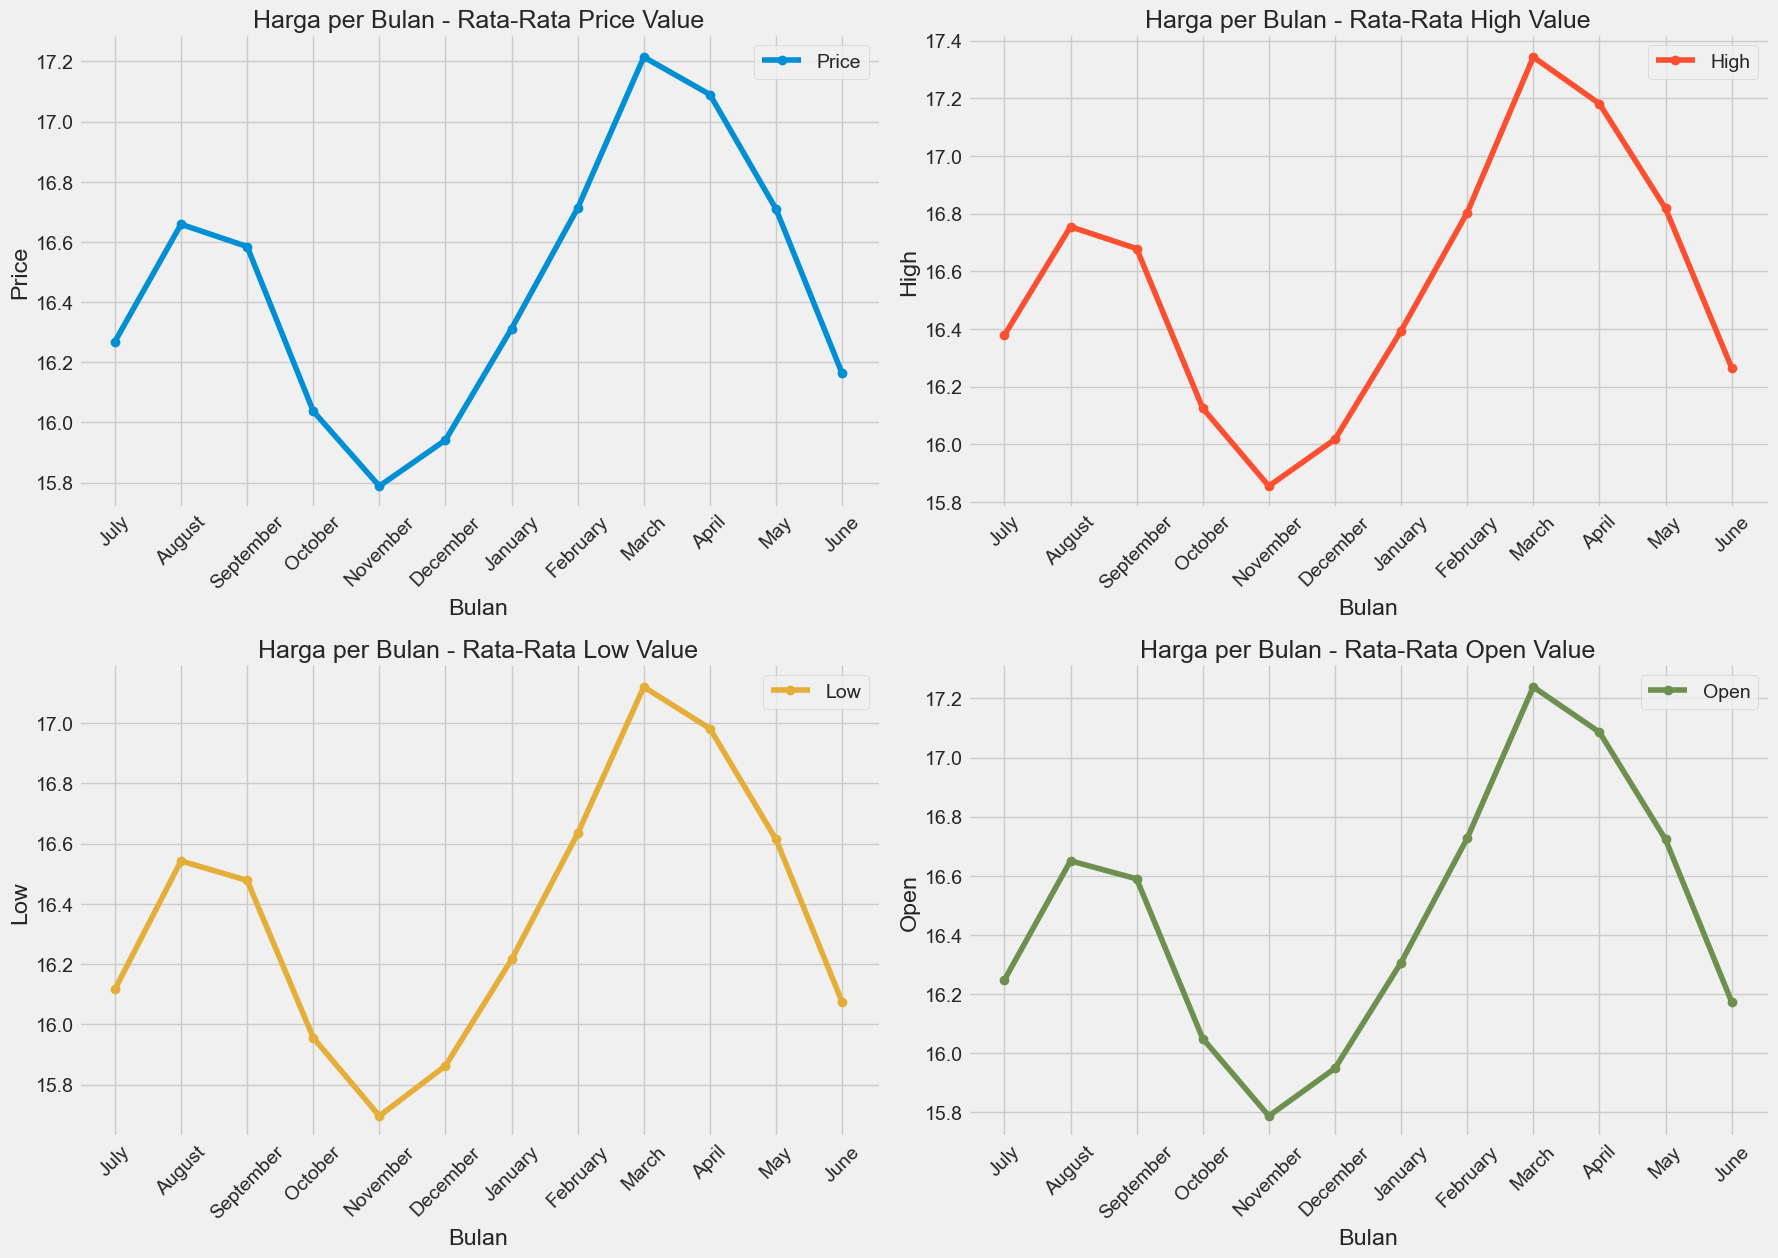

In [58]:
### mengonversi bagian tanggal ini menjadi format datetime yang sesuai
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

### mengatur kolom 'date' sebagai indeks (index) utama dari DataFrame stock_data.
stock_data.set_index('Date', inplace=True)

plt.rcParams['font.size'] = 14     #font size (ukuran huruf)
plt.rcParams['figure.dpi'] = 100    #resolusi gambar (dots per inch, DPI)
plt.rcParams['figure.figsize'] = (20, 10)  #mengatur lebar dan tinggi gambar
colors = plt.rcParams["axes.prop_cycle"]() #mengambil siklus warna (color cycle) yang didefinisikan dalam konfigurasi Matplotlib
a1 = 3  # inisialisasi variabel Jumlah baris
a2 = 2  # inisialisasi variabel Jumlah Kolom
a3 = 1  # inisialisasi Plot

# membuat objek gambar (figure) menjadi 18 inch lebar dan 18 inch tinggi
fig = plt.figure(figsize=(18, 18))

#  mendefinisikan daftar nama kolom yang akan diplot pada grafik
columns_to_plot = ['Price', 'High', 'Low', 'Open']

# Looping setiap kolom
for column in columns_to_plot:
    color = next(colors)["color"] #Warna ini akan digunakan untuk plot garis pada grafik.
    plt.subplot(a1, a2, a3) # membuat subplot dalam gambar  mengatur jumlah baris, jumlah kolom, dan nomor subplot

    # untuk menggambar data dalam bentuk grafik garis. Data yang digunakan adalah rerata (mean) dari kolom yang sedang diiterasi berdasarkan nama bulan
    plt.plot(stock_data.groupby(stock_data.index.month_name(), sort=False).mean()[column], color=color, marker='o')
    # untuk menghapus garis batas atas dan kanan pada subplot, sehingga plot akan terlihat lebih bersih
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # memutar label sumbu x sebesar 45 derajat
    plt.xticks(rotation=45)
    # mengatur judul grafik dengan mencakup nama kolom yang sedang diiterasi
    plt.title(f"Harga per Bulan - Rata-Rata {column} Value", fontsize=18)
    # mengatur label sumbu x dan sumbu y pada grafik
    plt.xlabel('Bulan')
    plt.ylabel(column)
    # menambahkan legenda (label keterangan) ke plot
    plt.legend([column])
    # Increment nomor subplot
    a3 = a3 + 1

# mengatur layout atau tata letak dari plot agar sesuai
plt.tight_layout()
# melihat plot yang dihasilkan
plt.show()

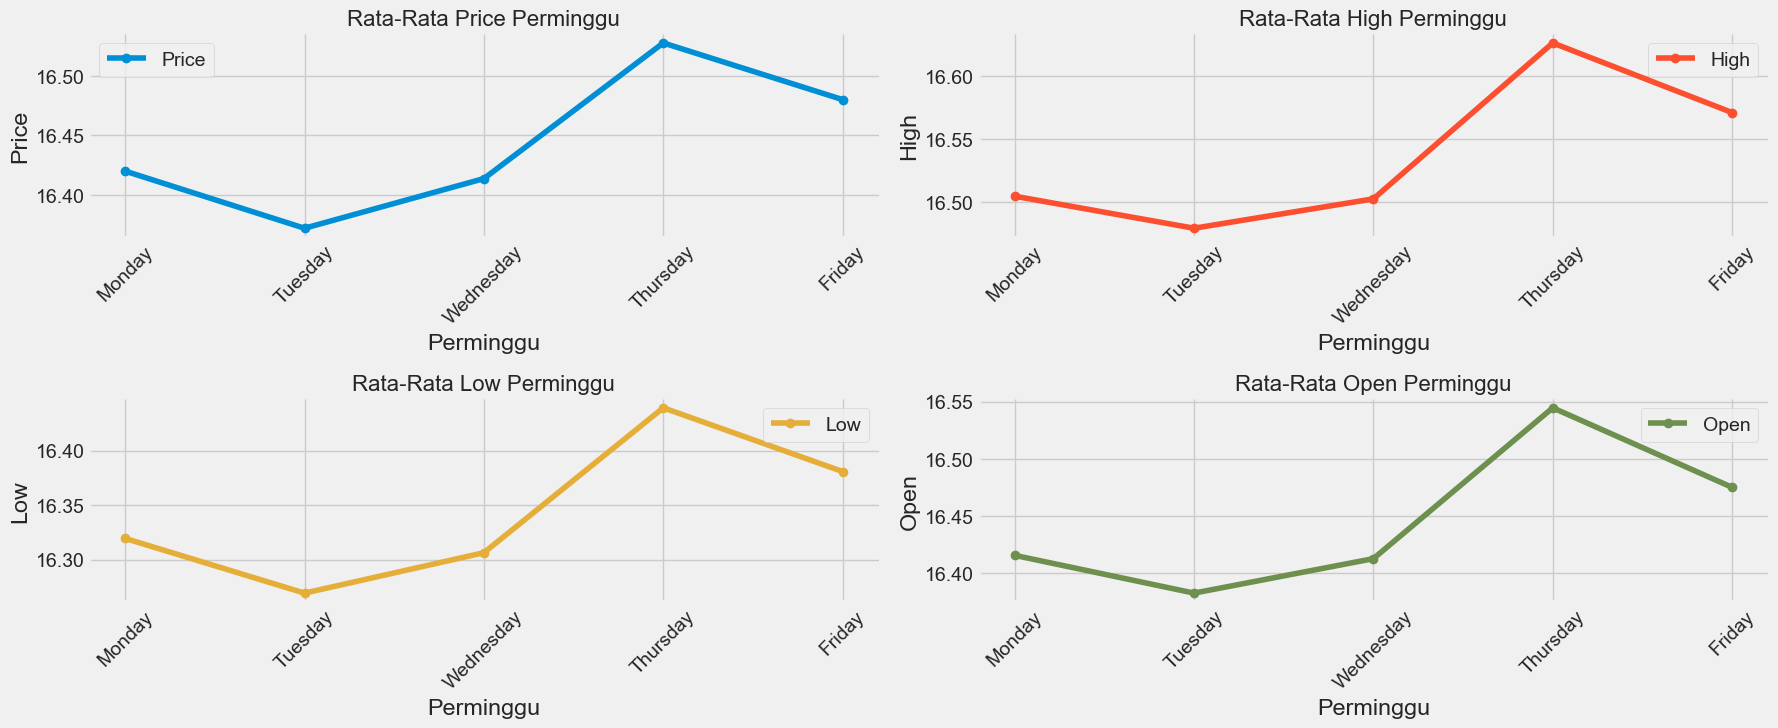

In [59]:
plt.rcParams['font.size'] = 14 #font size
plt.rcParams['figure.dpi'] = 100 #resolusi gambar
plt.rcParams['figure.figsize'] = (18, 10) #mengatur lebar dan tinggi gambar
colors = plt.rcParams["axes.prop_cycle"]() #mengambil siklus warna (color cycle) yang didefinisikan dalam konfigurasi Matplotlib
b1 = 3  # inisialisasi variabel Jumlah baris
b2 = 2  # inisialisasi variabel Jumlah kolom
b3 = 1  # inisialisasi plot

# membuat objek gambar (figure)
fig = plt.figure()

#  mendefinisikan daftar nama kolom yang akan diplot pada grafik
columns_to_plot = ['Price', 'High', 'Low', 'Open']

# Looping setiap kolom
for column in columns_to_plot:
    color = next(colors)["color"] #Warna ini akan digunakan untuk plot garis pada grafik.
    plt.subplot(b1, b2, b3) # membuat subplot dalam gambar  mengatur jumlah baris, jumlah kolom, dan nomor subplot

    # untuk menggambar data dalam bentuk grafik garis. Data yang digunakan adalah rerata (mean) dari kolom yang sedang diiterasi berdasarkan nama bulan
    plt.plot(stock_data.groupby(stock_data.index.day_name(), sort=False)[column].mean(), color=color, marker='o')
    # untuk menghapus garis batas atas dan kanan pada subplot, sehingga plot akan terlihat lebih bersih
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # memutar label sumbu x sebesar 45 derajat
    plt.xticks(rotation=45)
    # mengatur judul grafik dengan mencakup nama kolom yang sedang diiterasi
    plt.title(f"Rata-Rata {column} Perminggu", fontsize=16)
    # mengatur label sumbu x dan sumbu y pada grafik
    plt.xlabel('Perminggu')
    plt.ylabel(column)
    # menambahkan legenda (label keterangan) ke plot
    plt.legend([column])
    # Increment nomor subplot
    b3 += 1

# mengatur layout atau tata letak dari plot agar sesuai
plt.tight_layout()
# melihat plot yang dihasilkan
plt.show()

# Modeling Dan Visualisasi MA 50 dan RSI

# MA(Moving Average) 50

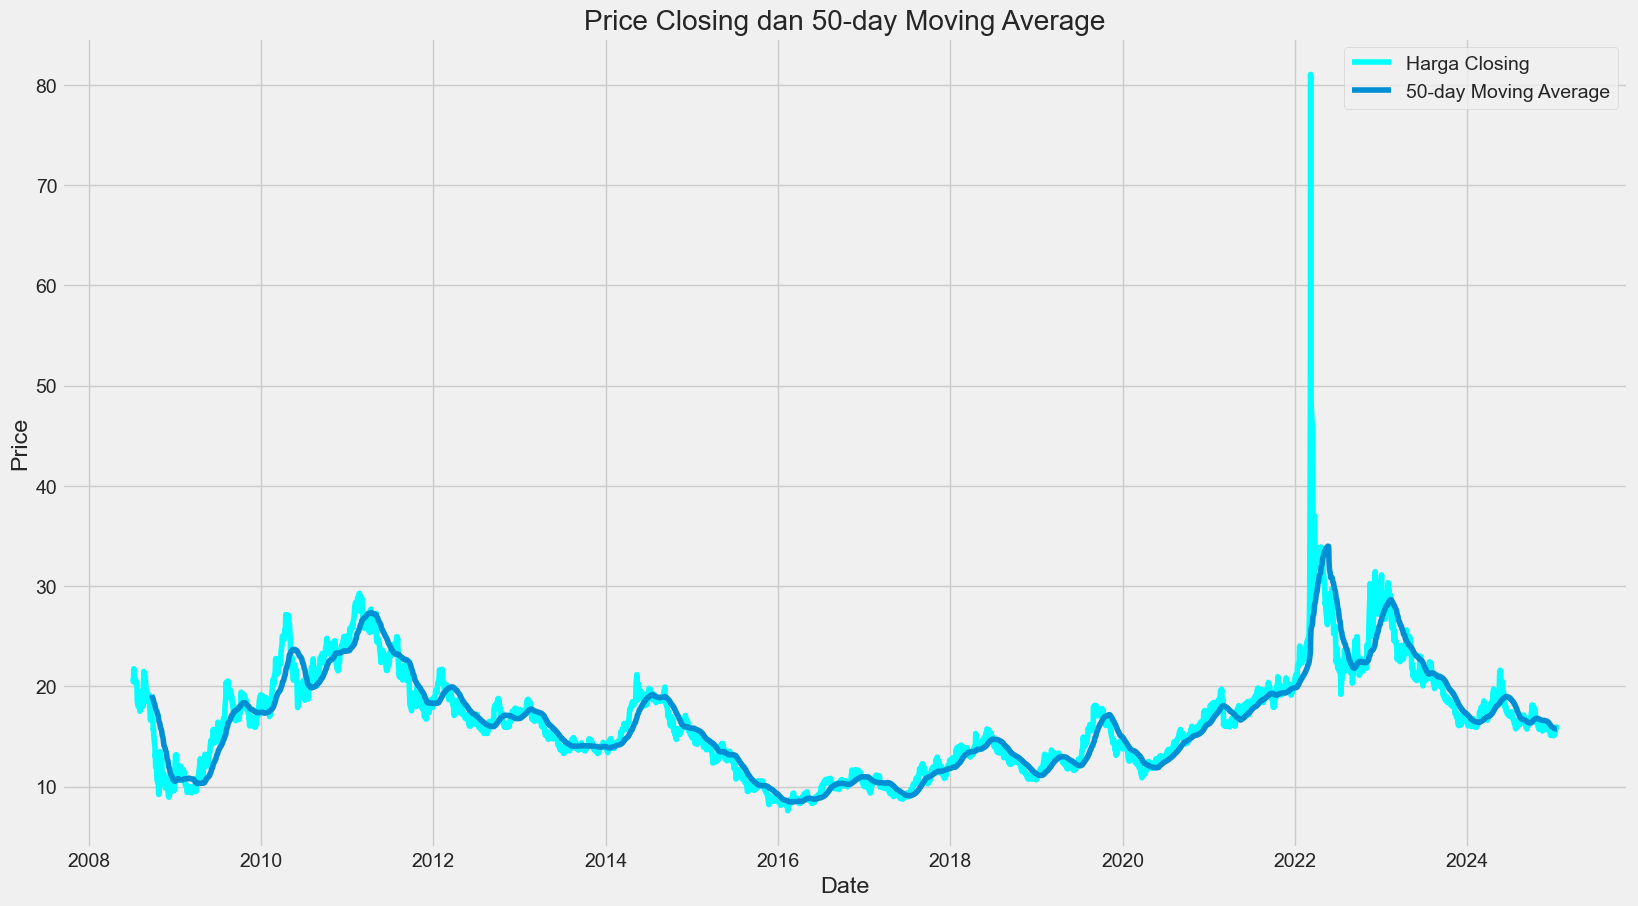

In [60]:
rolling_avg = stock_data['Price'].rolling(window=50).mean() #menghitung rata-rata 50 hari dari harga penutupan saham

plt.plot(stock_data['Price'], label='Harga Closing',color='cyan') #Menggambar grafik,mengambil date, dan close
plt.plot(rolling_avg, label='50-day Moving Average') #menggambar grafik,mengambil date, dan rata2 50 hari close
##plt.plot(stock_data['date'], rolling_avg, label='20-day Moving Average')
plt.xlabel('Date') #mengatur label sumbu x menjadi tanggal
plt.ylabel('Price')   #mengatur label sumbu y menjadi harga
plt.title('Price Closing dan 50-day Moving Average') #mengatur judul grafik atau title
  # menambahkan legenda (label keterangan) ke plot
plt.legend()
#menampilkan hasil
plt.show()

Ketika harga penutupan (close) suatu aset atau saham berada di bawah rata-rata bergerak 50 hari (MA 50), itu dapat mengindikasikan adanya tren penurunan atau sentimen bearish dalam pergerakan harga

# RSI(Relative Strength Index)

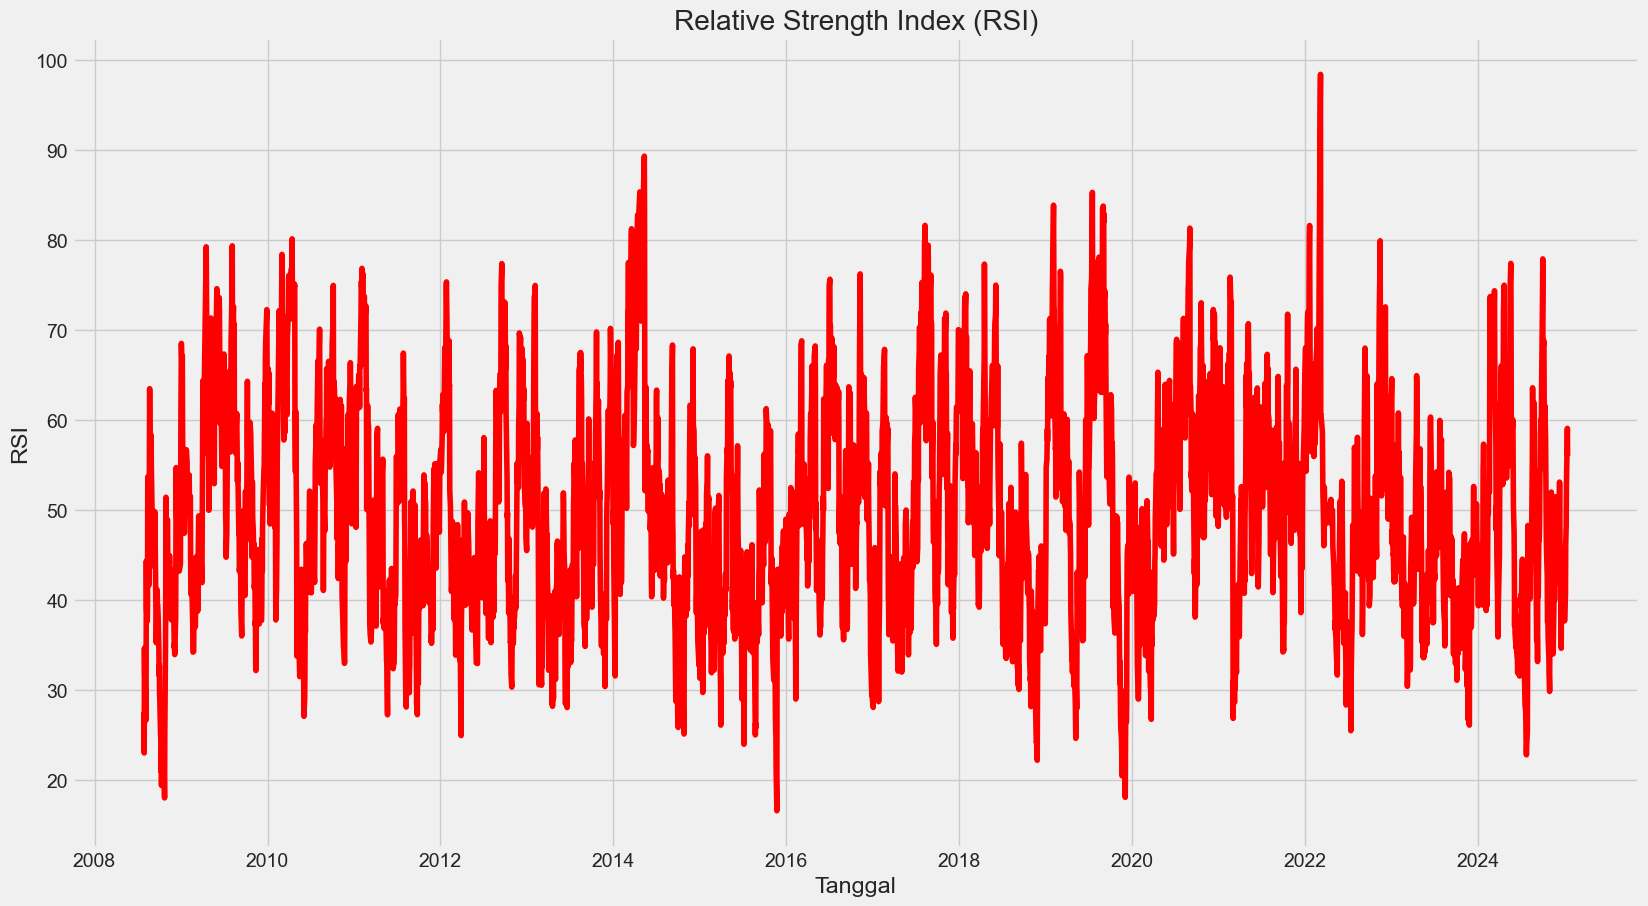

In [61]:
rsi = ta.momentum.RSIIndicator(stock_data['Price']).rsi() # menggunakan TA-Lib (Technical Analysis Library) untuk menghitung RSI dari data harga penutupan saham

plt.plot(rsi, color='red')  #menggambar grafik, mengambil colom date
plt.xlabel('Tanggal') #mengatur label x menjadi tanggal
plt.ylabel('RSI') #mengatur label y menjadi RSI
plt.title('Relative Strength Index (RSI)') #mengatur judul atau title
plt.show() #menampilakn hasil

Di bawah 30 mengindikasikan kondisi oversold, sementara di atas 70 mengindikasikan kondisi overbought, jika nilai RSI berada di bawah 30, ini adalah tanda bahwa aset tersebut mungkin oversold, yang dapat mengindikasikan bahwa penurunan harga berpotensi berhenti atau bahkan pembalikan tren naik mungkin terjadi

RSI = 100 - (100 / (1 + (Average Gain / Average Loss))

# Visualisasi dan Modeling LSTM

In [62]:
stock_data #melihat dataset

,Price,Open,High,Low
Date,,,,
2008-07-07,20.785,20.785,20.785,20.785
2008-07-08,20.460,20.460,20.460,20.460
2008-07-09,21.309,21.309,21.309,21.309
2008-07-10,21.760,21.760,21.760,21.760
2008-07-11,21.455,21.455,21.455,21.455
...,...,...,...,...
2025-01-09,15.482,15.450,15.400,15.450
2025-01-10,15.658,15.620,15.590,15.600
2025-01-13,15.901,15.780,15.775,15.780


In [63]:
stock_data = stock_data[['Price', 'High', 'Low', 'Open']] # extract colom yang telah di sesuaikan hanya 4 kolom

In [64]:
#melakukan penskalaan data ke dalam rentang tertentu
#membuat sebuah objek yang di simpan dalam variabel MMS
MMS = MinMaxScaler()
#melakukan penskalaan Min-Max pada DataFrame
stock_data[stock_data.columns] = MMS.fit_transform(stock_data)
stock_data

,Price,High,Low,Open
Date,,,,
2008-07-07,0.179619,0.164174,0.180115,0.178856
2008-07-08,0.175195,0.160059,0.175692,0.174429
2008-07-09,0.186752,0.170810,0.187246,0.185994
2008-07-10,0.192891,0.176520,0.193383,0.192137
2008-07-11,0.188740,0.172658,0.189233,0.187983
...,...,...,...,...
2025-01-09,0.107431,0.095985,0.107511,0.106183
2025-01-10,0.109827,0.098391,0.109552,0.108499
2025-01-13,0.113135,0.100733,0.112002,0.110678


In [65]:
stock_data.shape #mendapatkan bentuk (shape) dari sebuah objek

(4078, 4)

In [66]:
#digunakan untuk pelatihan (training size) dalam konteks pembagian data menjadi data pelatihan dan data pengujian (training and testing data) 80%:20%
training_size = round(len(stock_data) * 0.80)
training_size

3262

In [67]:
#split data
train_data = stock_data[:training_size] #data train
test_data  = stock_data[training_size:] #data test

train_data.shape, test_data.shape    #train dan tes tetap berjumlah 4 kolom dari shape

((3262, 4), (816, 4))

# Visualisasi Pembagian Data Training dan Testing

Train dates : 2008-07-07 00:00:00 --- 2021-10-15 00:00:00  (n=3262)
Test dates  : 2021-10-18 00:00:00 --- 2025-01-15 00:00:00  (n=816)



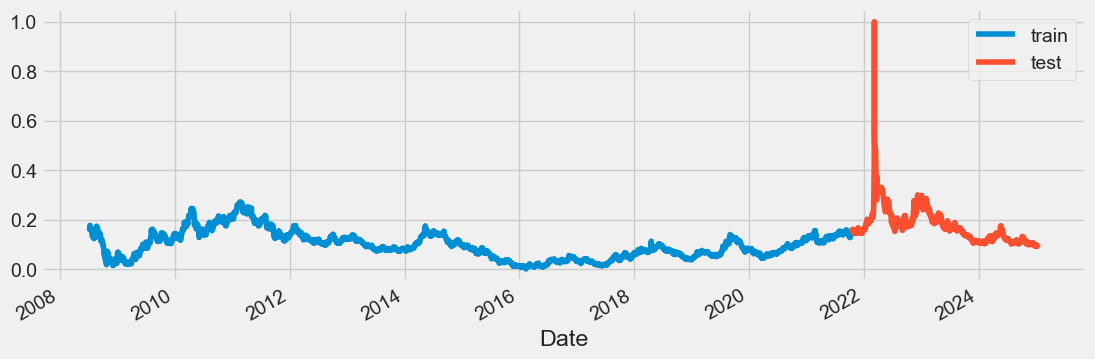

In [68]:
# train & test data split
# **************************************************************************************************************
# size = 187  # last n days
# train_data = stock_data[:-size]
# test_data  = stock_data[-size:]

print(f"Train dates : {train_data.index.min()} --- {train_data.index.max()}  (n={len(train_data)})")
print(f"Test dates  : {test_data.index.min()} --- {test_data.index.max()}  (n={len(test_data)})")
print()


# plot the training & validation data
# **************************************************************************************************************

col = 'High'
fig, ax = plt.subplots(figsize=(12, 4))
train_data[col].plot(ax=ax, label='train')
test_data[col].plot(ax=ax, label='test')
ax.legend();

In [69]:
# fungsi untuk membuat sequence data training dan data testing ( membuat urutan data )
#menyimpan urutan data (sequences) dan label yang sesuai
def create_sequence(dataset):
  sequences = []
  labels = []

  start_idx = 0 #indeks awal dari rentang data

  for stop_idx in range(50,len(dataset)): # dimulai dari indeks 50 dan berakhir pada panjang dataset
    sequences.append(dataset.iloc[start_idx:stop_idx]) #mengumpulkan urutan data yang akan digunakan untuk pelatihan atau pengujian.
    labels.append(dataset.iloc[stop_idx]) #label yang sesuai dengan urutan data tersebut, dan label ini ditambahkan ke dalam list
    start_idx += 1 #Setiap kali kita selesai dengan satu iterasi akan ditambah 1
  return (np.array(sequences),np.array(labels)) #ubah menjadi numpy array dan mengembalikan keduanya sebagai tuple

In [70]:
#membuat urutan data pelatihan (training data) dan pengujian (testing data)
X_train, y_train = create_sequence(train_data)
X_test, y_test = create_sequence(test_data)

In [71]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape # shape memeriksa jumlah baris dan kolom setelah di split

((3212, 50, 4), (3212, 4), (766, 50, 4), (766, 4))

In [72]:
# Model BiGRU
from tensorflow.keras.layers import GRU,Bidirectional

regressor = Sequential()

regressor.add(Bidirectional(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))))
              
regressor.add(Dropout(0.2))

regressor.add(Bidirectional(GRU(units = 50, return_sequences = True)))
regressor.add(Dropout(0.2))

regressor.add(Bidirectional(GRU(units = 50, return_sequences = True)))
regressor.add(Dropout(0.2))

regressor.add(Bidirectional(GRU(units = 50)))
regressor.add(Dropout(0.2))

regressor.add(Dense(units = 4))



In [73]:
regressor.compile(optimizer = Adam(learning_rate=0.001), loss = 'mean_squared_error',metrics=['mean_absolute_error'])
regressor.fit(X_train, y_train, epochs = 100, batch_size = 64)

Epoch 1/100
51/51 [==============================] - 39s 151ms/step - loss: 0.0013 - mean_absolute_error: 0.0238
Epoch 2/100
51/51 [==============================] - 8s 147ms/step - loss: 2.9172e-04 - mean_absolute_error: 0.0124
Epoch 3/100
51/51 [==============================] - 7s 146ms/step - loss: 2.6150e-04 - mean_absolute_error: 0.0118
Epoch 4/100
51/51 [==============================] - 7s 145ms/step - loss: 2.0814e-04 - mean_absolute_error: 0.0105
Epoch 5/100
51/51 [==============================] - 8s 148ms/step - loss: 1.9791e-04 - mean_absolute_error: 0.0103
Epoch 6/100
51/51 [==============================] - 8s 156ms/step - loss: 1.8454e-04 - mean_absolute_error: 0.0101
Epoch 7/100
51/51 [==============================] - 8s 154ms/step - loss: 1.7392e-04 - mean_absolute_error: 0.0096
Epoch 8/100
51/51 [==============================] - 8s 149ms/step - loss: 1.6017e-04 - mean_absolute_error: 0.0092
Epoch 9/100
51/51 [==============================] - 7s 143ms/step - loss: 

# hasil

In [74]:
train_loss, train_mae = regressor.evaluate(X_train, y_train, verbose=0)
print('Akurasi training:', 1 - train_mae)

Akurasi training: 0.9966281105298549


In [75]:
# Evaluasi model pada data testing
test_loss, test_mae = regressor.evaluate(X_test, y_test, verbose=0)
acu_test = 1 - test_mae
print('Akurasi testing:', acu_test)

Akurasi testing: 0.9930604589171708


In [76]:
for layer in regressor.layers:
    if hasattr(layer, 'bias'):
        print(layer.name, layer.bias.numpy())

dense_1 [0.10308686 0.09487257 0.1021905  0.10255604]


In [77]:
#membuat prediksi berdasarkan data pengujian (test data) 5 data pertama
test_predicted = regressor.predict(X_test)
test_predicted[:5]

24/24 [==============================] - 9s 28ms/step


array([[0.16947146, 0.15529963, 0.16845813, 0.16820887],
       [0.17197213, 0.15765598, 0.17094323, 0.17073536],
       [0.17517838, 0.16065773, 0.17412204, 0.17396486],
       [0.17796318, 0.1632078 , 0.176938  , 0.17676511],
       [0.17932892, 0.16454804, 0.17821786, 0.17814043]], dtype=float32)

In [78]:
# mengambil data hasil prediksi yang telah disesuaikan dengan scaling dan mengembalikannya ke dalam skala aslinya
test_inverse_predicted = MMS.inverse_transform(test_predicted) # inversing scaling predidksi data
test_inverse_predicted[:5]

array([[20.039543, 20.084167, 19.928473, 20.00338 ],
       [20.223244, 20.270252, 20.11108 , 20.188852],
       [20.458778, 20.507303, 20.344662, 20.425934],
       [20.663353, 20.708683, 20.55158 , 20.631502],
       [20.763681, 20.814524, 20.645626, 20.732466]], dtype=float32)

In [79]:
# regressor.save('regressor.h5')

# joblib.dump(MMS, 'scaler.joblib')

In [80]:
# loaded_regressor = load_model('model_regressor.h5')

In [81]:
print(len(test_data)-50)

766


In [82]:
#menggabungkan (merge) dua set data menggunakan perpustakaan Pandas (pandas.concat).

merge_data = pd.concat([stock_data.iloc[-(len(test_data)-50):].copy(),pd.DataFrame(test_inverse_predicted,columns=['high_predicted','low_predicted','open_predicted','close_predicted'],index=stock_data.iloc[-(len(test_data)-50):].index)], axis=1)

In [83]:
# memungkinkan  untuk membandingkan prediksi dengan data historis dengan lebih mudah dalam konteks skala aslinya
merge_data[['Price', 'High', 'Low', 'Open']] = MMS.inverse_transform(merge_data[['Price', 'High', 'Low', 'Open']]) # Inverse scaling

In [84]:
merge_data.head() #mengetahui beberapa barus pertama dari dataframe

,Price,High,Low,Open,high_predicted,low_predicted,open_predicted,close_predicted
Date,,,,,,,,
2021-12-29,20.383,20.20,20.215,20.230,20.039543,20.084167,19.928473,20.003380
2021-12-30,20.587,20.49,20.500,20.525,20.223244,20.270252,20.111080,20.188852
2021-12-31,20.757,20.75,20.750,20.800,20.458778,20.507303,20.344662,20.425934
2022-01-04,21.137,20.59,20.600,20.625,20.663353,20.708683,20.551580,20.631502
2022-01-05,20.638,20.73,20.740,20.775,20.763681,20.814524,20.645626,20.732466


In [85]:
merge_data

,Price,High,Low,Open,high_predicted,low_predicted,open_predicted,close_predicted
Date,,,,,,,,
2021-12-29,20.383,20.200,20.215,20.230,20.039543,20.084167,19.928473,20.003380
2021-12-30,20.587,20.490,20.500,20.525,20.223244,20.270252,20.111080,20.188852
2021-12-31,20.757,20.750,20.750,20.800,20.458778,20.507303,20.344662,20.425934
2022-01-04,21.137,20.590,20.600,20.625,20.663353,20.708683,20.551580,20.631502
2022-01-05,20.638,20.730,20.740,20.775,20.763681,20.814524,20.645626,20.732466
...,...,...,...,...,...,...,...,...
2025-01-09,15.482,15.400,15.450,15.450,15.545630,15.630398,15.422636,15.523807
2025-01-10,15.658,15.590,15.600,15.620,15.575379,15.664265,15.448472,15.553173
2025-01-13,15.901,15.775,15.780,15.780,15.710356,15.803604,15.578844,15.688955


In [86]:
merge_data['high_predicted'].max()

69.305244

In [87]:
merge_data['high_predicted'].min()

15.208932

# Visualisasi dari Harga Tertinggi Actual dan Prediksinya

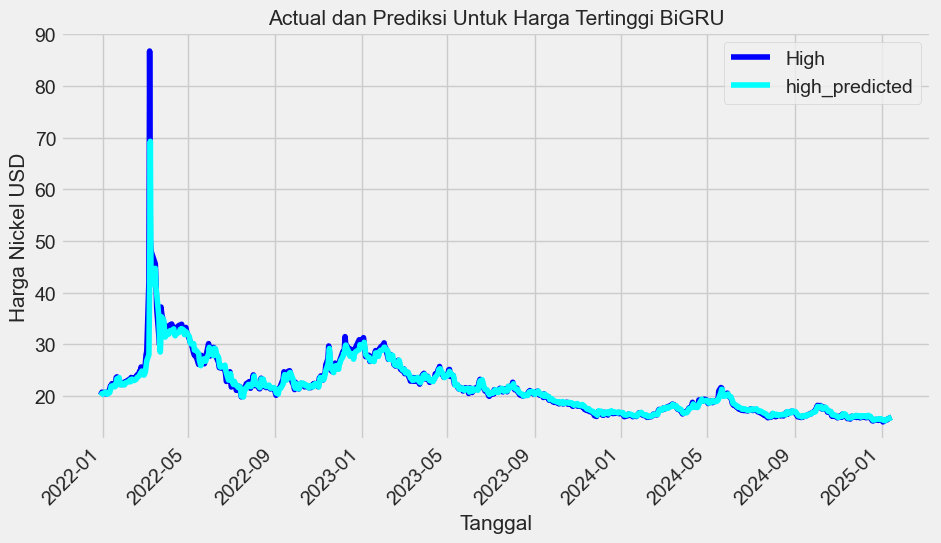

In [88]:
# membandingkan harga saham sebenarnya ('high') dengan prediksi harga tertinggi ('high_predicted') dalam suatu periode waktu.
merge_data[['High','high_predicted']].plot(figsize=(10,6),color=['blue', 'cyan'])
plt.xticks(rotation=45)
plt.xlabel('Tanggal',size=15)
plt.ylabel('Harga Nickel USD',size=15)
plt.title('Actual dan Prediksi Untuk Harga Tertinggi BiGRU',size=15)
plt.show()

In [89]:
new_dates = pd.DataFrame(columns=merge_data.columns,index=pd.date_range(start=merge_data.index[-1],periods=10, freq='D'))
new_dates

,Price,High,Low,Open,high_predicted,low_predicted,open_predicted,close_predicted
2025-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
merge_data_2 = pd.concat([merge_data, new_dates])

In [91]:
#menggunakan DataFrame ini untuk menyimpan hasil prediksi atau data masa depan
upcoming_prediction = pd.DataFrame(columns=['Price', 'High', 'Low', 'Open'],index=merge_data_2.index)
upcoming_prediction.index=pd.to_datetime(upcoming_prediction.index)

In [92]:
#membuat prediksi harga saham untuk periode masa depan menggunakan model regresi (regressor)
curr_seq = X_test[-1:]

for i in range(-10,0):
  up_pred = regressor.predict(curr_seq)
  upcoming_prediction.iloc[i] = up_pred
  curr_seq = np.append(curr_seq[0][1:],up_pred,axis=0)
  curr_seq = curr_seq.reshape(X_test[-1:].shape)

1/1 [==============================] - 0s 57ms/step


In [93]:
#mengembalikan hasil prediksi model ke dalam skala aslinya sehingga hasilnya dapat digunakan atau dievaluasi dengan lebih baik dalam konteks data historis atau data aktual.
upcoming_prediction[['Price', 'High', 'Low', 'Open']] = MMS.inverse_transform(upcoming_prediction[['Price', 'High', 'Low', 'Open']])

In [94]:
upcoming_prediction

,Price,High,Low,Open
2021-12-29,NaN,NaN,NaN,NaN
2021-12-30,NaN,NaN,NaN,NaN
2021-12-31,NaN,NaN,NaN,NaN
2022-01-04,NaN,NaN,NaN,NaN
2022-01-05,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-01-20,16.262306,16.356969,16.128148,16.247107
2025-01-21,16.330154,16.425598,16.193709,16.312749
2025-01-22,16.393090,16.489874,16.254137,16.373918
2025-01-23,16.447481,16.546302,16.304745,16.427454


# Visualisasi Kemungkinan Prediksi yang Akan Datang, dalam visualisasi ini dengan variabel High

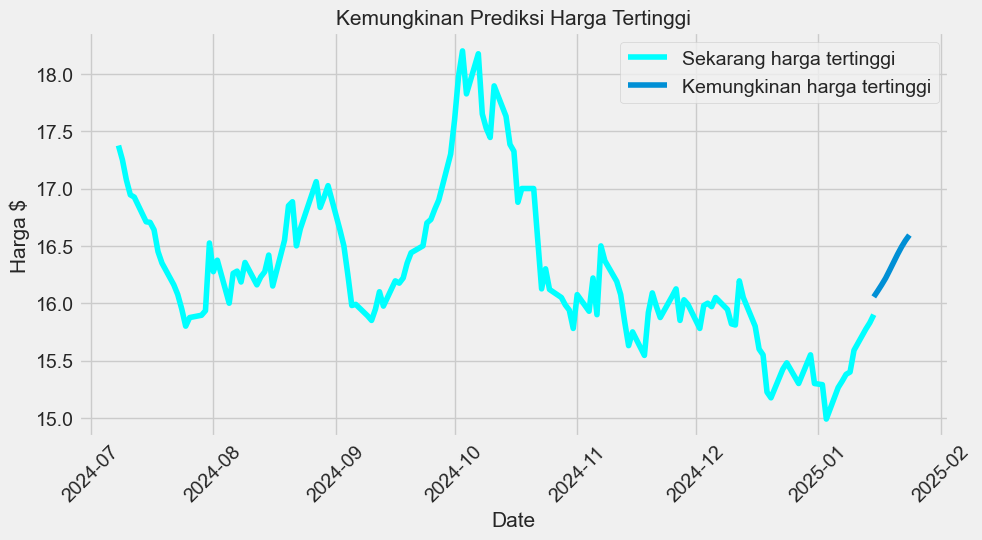

In [95]:
fg,ax=plt.subplots(figsize=(10,5))
ax.plot(merge_data_2.loc['2024-07-07':,'High'],label='Sekarang harga tertinggi',color='cyan')
ax.plot(upcoming_prediction.loc['2008-07-07':,'High'],label='Kemungkinan harga tertinggi')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Date',size=15)
ax.set_ylabel('Harga $',size=15)
ax.set_title('Kemungkinan Prediksi Harga Tertinggi',size=15)
ax.legend()
fg.show()

# Evaluasi Model MSE, RMSE, R2 SCORE

In [96]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score, explained_variance_score

# Menghitung Mean Squared Error (MSE)
mse = mean_squared_error(y_test, test_predicted)
print("Mean Squared Error (MSE):", mse)

# Menghitung Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

# Menghitung Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, test_predicted)
print("Mean Absolute Error (MAE):", mae)

# Menghitung R-squared (R2) Score
r2 = r2_score(y_test, test_predicted)
print("R-squared (R2) Score:", r2)

# Menampilkan prediksi harga tertinggi
tertinggi = merge_data_2['High'].max()
print(f'Prediksi harga tertinggi : $',tertinggi)

print('Accuracy : ', acu_test)


Mean Squared Error (MSE): 0.0006181568472051582
Root Mean Squared Error (RMSE): 0.024862760249118723
Mean Absolute Error (MAE): 0.006939540354647007
R-squared (R2) Score: 0.8850163773729005
Prediksi harga tertinggi : $ 86.791
Accuracy :  0.9930604589171708
